# CAWCR - Satellite Comparison

### Creating buoy nc file from csv file

The data csv data were obtained with the code xxxx. Before, using the CalVal code, it is needed to convert all the necessary data to a compatible format

In [ ]:
import pandas as pd
import xarray as xr
import numpy as np
from datetime import datetime
import gc

def get_units(var):
    """Return the appropriate units for each variable."""
    units = {
        'Hs_Buoy': 'm',
        'Tm_Buoy': 's',
        'Tp_Buoy': 's',
        'Dir_Buoy': 'degrees',
        'DirP_Buoy': 'degrees',
        'Spr_Buoy': 'degrees',
        'SprP_Buoy': 'degrees'
    }
    return units.get(var, '')

def get_long_name(var):
    """Return the long name for each variable."""
    names = {
        'Hs_Buoy': 'Significant Wave Height',
        'Tm_Buoy': 'Mean Wave Period',
        'Tp_Buoy': 'Peak Wave Period',
        'Dir_Buoy': 'Mean Wave Direction',
        'DirP_Buoy': 'Peak Wave Direction',
        'Spr_Buoy': 'Directional Spreading',
        'SprP_Buoy': 'Peak Directional Spreading'
    }
    return names.get(var, '')

def csv_to_nc_for_calval(input_csv, output_nc, latitude, longitude, station_id, chunksize=10000):
    """
    Convert buoy CSV data to NetCDF format for CalVal.
    
    Parameters:
    -----------
    input_csv : str
        Path to input CSV file
    output_nc : str
        Path to output NetCDF file
    latitude : float
        Buoy latitude
    longitude : float
        Buoy longitude
    station_id : int
        Station ID (codigo_oppe)
    chunksize : int, optional
        Number of rows to process at a time (default: 10000)
    """
    # Get total number of rows first
    print("Counting total rows...")
    total_rows = sum(1 for _ in open(input_csv))
    print(f"Total rows: {total_rows}")
    
    # Initialize arrays to store data
    data_arrays = {}
    timestamps = []
    
    # Process the CSV file in chunks
    print("Processing CSV file in chunks...")
    chunk_count = 0
    for chunk in pd.read_csv(input_csv, chunksize=chunksize):
        chunk_count += 1
        print(f"Processing chunk {chunk_count}/{(total_rows//chunksize)+1}")
        
        # Create datetime index for this chunk
        chunk_times = pd.to_datetime(
            chunk['YYYY'].astype(str) + '-' + 
            chunk['MM'].astype(str).str.zfill(2) + '-' + 
            chunk['DD'].astype(str).str.zfill(2) + ' ' + 
            chunk['hh'].astype(str).str.zfill(2) + ':' + 
            chunk['mm'].astype(str).str.zfill(2)
        )
        timestamps.extend(chunk_times)
        
        # Process each variable
        for col in ['WVHT', 'APD', 'DPD', 'MWD']:
            # Initialize array if first chunk
            if col not in data_arrays:
                data_arrays[col] = []
            
            # Clean the data
            if col in ['WVHT', 'DPD']:
                # Replace 99.0 with NaN for wave height and period
                clean_data = chunk[col].replace(99.0, np.nan)
            elif col == 'MWD':
                # Replace 999 with NaN for direction
                clean_data = chunk[col].replace(999, np.nan)
            else:
                clean_data = chunk[col]
            
            # Additional data cleaning
            if col == 'WVHT':
                clean_data = clean_data.where((clean_data >= 0) & (clean_data <= 15), np.nan)
            elif col == 'DPD':
                clean_data = clean_data.where((clean_data >= 0) & (clean_data <= 25), np.nan)
            elif col == 'MWD':
                clean_data = clean_data.where((clean_data >= 0) & (clean_data <= 360), np.nan)
            
            data_arrays[col].extend(clean_data)
        
        # Free memory
        del chunk
        gc.collect()
    
    # Convert lists to numpy arrays
    print("Converting to numpy arrays...")
    for key in data_arrays:
        data_arrays[key] = np.array(data_arrays[key], dtype=np.float32)
    timestamps = np.array(timestamps)
    
    # Sort by time and remove duplicates
    print("Sorting and removing duplicates...")
    unique_indices = np.unique(timestamps, return_index=True)[1]
    timestamps = timestamps[unique_indices]
    
    for key in data_arrays:
        data_arrays[key] = data_arrays[key][unique_indices]
    
    # Create xarray dataset with the exact format needed
    print("Creating xarray dataset...")
    ds = xr.Dataset(
        {
            'Hs_Buoy': ('time', data_arrays['WVHT']),
            'Tm_Buoy': ('time', data_arrays['APD']),
            'Tp_Buoy': ('time', data_arrays['DPD']),
            'Dir_Buoy': ('time', data_arrays['MWD']),
            'DirP_Buoy': ('time', data_arrays['MWD']),  # Using MWD as peak direction
            'Spr_Buoy': ('time', np.full_like(data_arrays['MWD'], np.nan)),  # Not available
            'SprP_Buoy': ('time', np.full_like(data_arrays['MWD'], np.nan))  # Not available
        },
        coords={
            'time': timestamps
        }
    )
    
    # Add variable attributes (without _FillValue)
    for var in ds.data_vars:
        ds[var].attrs = {
            'units': get_units(var),
            'long_name': get_long_name(var)
        }
    
    # Add global attributes
    ds.attrs = {
        'codigo_oppe': station_id,
        'longitude': longitude,
        'latitude': latitude,
        'creation_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'data_source': 'NDBC',
        'station_id': f'NDBC_{station_id}',
        'description': 'Buoy data processed for wave model validation'
    }
    
    # Save to NetCDF file with chunking and compression
    print("Saving to NetCDF file...")
    encoding = {
        var: {
            'zlib': True,
            'complevel': 5,
            'chunksizes': (min(10000, len(timestamps)),),
            '_FillValue': np.nan
        } for var in ds.data_vars
    }
    encoding['time'] = {'zlib': True, 'complevel': 5}
    
    ds.to_netcdf(
        output_nc,
        encoding=encoding
    )
    
    # Print summary
    print("\nDataset summary:")
    print(f"Time range: {ds.time[0].values} to {ds.time[-1].values}")
    print(f"Number of timestamps: {len(ds.time)}")
    print(f"Variables: {list(ds.variables)}")
    print(f"\nSuccessfully converted {input_csv} to {output_nc}")
    
    return ds

if __name__ == "__main__":
    # File paths
    input_csv = "/Users/sam/jen/data_carolinas/buoys/44100/buoy_44100_combined.csv"
    output_nc = "/Users/sam/jen/code/GeoOcean_codes/CalValWaves/data/buoy/buoy_44100.nc"
    
    
    # Buoy metadata
    latitude = 36.2580 # Carolinas buoy latitude
    longitude = -75.5930   # Carolinas buoy longitude
    station_id = 44100  # Using the codigo_oppe from the example
    
    # Convert file with chunking
    ds = csv_to_nc_for_calval(input_csv, output_nc, latitude, longitude, station_id)

In [ ]:
# matching time with hindcast data

import pandas as pd
import xarray as xr
import numpy as np
from datetime import datetime, timedelta
import os.path as op
import os

def align_buoy_data():
    """Align buoy data timestamps with hindcast data and save to new netCDF."""
    print("Loading data...")
    
    # Load data
    p_data = op.join(os.getcwd(), '..', 'data')
    buoy = xr.open_dataset(op.join(p_data, 'buoy', 'buoy_44100.nc'))
    
    # Convert buoy time to pandas datetime
    time = pd.to_datetime(buoy.time.values)
    
    # Function to round time to nearest hour
    def round_to_hour(dt):
        if dt.minute >= 30:
            return dt.replace(minute=0, second=0, microsecond=0) + timedelta(hours=1)
        return dt.replace(minute=0, second=0, microsecond=0)
    
    # Round all timestamps to nearest hour
    new_time = np.array([round_to_hour(t) for t in time])
    
    # Create new dataset with aligned timestamps
    new_buoy = buoy.copy()
    new_buoy['time'] = new_time
    
    # Sort by time to ensure proper ordering
    new_buoy = new_buoy.sortby('time')
    
    # Remove duplicates by taking mean of measurements at same timestamp
    new_buoy = new_buoy.groupby('time').mean()
    
    # Save aligned data
    output_file = op.join(p_data, 'buoy', 'buoy_44100_aligned.nc')
    new_buoy.to_netcdf(output_file)
    print(f"\nSaved aligned buoy data to: {output_file}")
    
    # Print statistics
    print("\nOriginal data:")
    print(f"Time range: {time.min()} to {time.max()}")
    print(f"Number of measurements: {len(time)}")
    print(f"Sample timestamps:")
    for t in time[:5]:
        print(f"  {t}")
    
    print("\nAligned data:")
    print(f"Time range: {new_time.min()} to {new_time.max()}")
    print(f"Number of measurements: {len(np.unique(new_time))}")
    print(f"Sample timestamps:")
    for t in sorted(set(new_time))[:5]:
        print(f"  {t}")

if __name__ == "__main__":
    align_buoy_data()

## Here starts the Original Code

In [2]:
# common
import sys
import os
import os.path as op

# basic
import numpy as np
import pandas as pd
import xarray as xr
from time import time
import warnings
warnings.simplefilter('ignore')

# append calval to path
sys.path.insert(0, os.path.join(os.path.abspath(''), '..'))

# custom
from calval import calval

# functions
from calval import functions

In [3]:
# initial time to see the duration of the notebook
t0 = time()

In [4]:
# data 
p_data = op.join(os.getcwd(), '..', 'data')

lon_360=-75.6+360
csiro      =  pd.read_pickle(op.join(p_data, 'hindcast', 'csiro_dataframe_carolinas_44100_1983_2024.pkl'))
csiro_lon, csiro_lat = lon_360, 36.4 # add lon / lat coordinates of csiro node in 360?
satellite  =  xr.open_dataset(op.join(p_data, 'satellite', 'satellite_dataset_carolinas_test4.nc'))
buoy       =  xr.open_dataset(op.join(p_data, 'buoy', 'buoy_44100_aligned.nc'))

print('---------------------------------------------------')
print('Time wasted reading the data: ' + str(round(time()-t0, 2)) + ' s')
print('---------------------------------------------------')

---------------------------------------------------
Time wasted reading the data: 2.1 s
---------------------------------------------------


In [5]:
t1 = time()


 Plotting region to be working with!! 



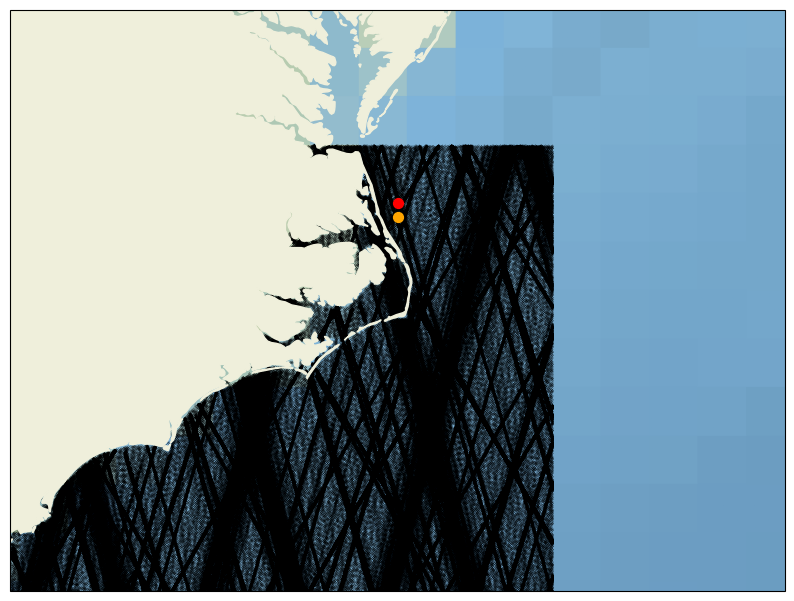

 -------------------------------------------------------- 
SATELLITE CALIBRATION will be performed
 -------------------------------------------------------- 
 
Satellite box values: 
 
 
Selecting the satellite data choosed... 
 
Satellite length: 302941
Hindcast information able to calibrate: 266616 
 
Choose the way to calibrate the data: 
 
 
Performing the time calibration... 
 
Length of data to calibrate: 113978 
 
 
 
Constructing matrices and calibrating... 
 
This might take a few minutes... 

Sea... 

0.0% completed...
50.0% completed...


Swells 1, 2, 3... 

0.0% completed...
50.0% completed...
0.0% completed...
50.0% completed...


Threshold of minimum Hs to calibrate
Directional families with a mean Hs under this threshold will not be calibrated: 
 
 
 
 
Params used for the SATELLITE calibration are: 
 
[1.19180567 1.33202132 1.56038342 1.5146654  2.4059173  1.63500406
 1.48445343 1.36265261 1.21892176 1.93120783 2.14718343 1.87412345
 1.87036128 1.67351552 1.65065137 1.4

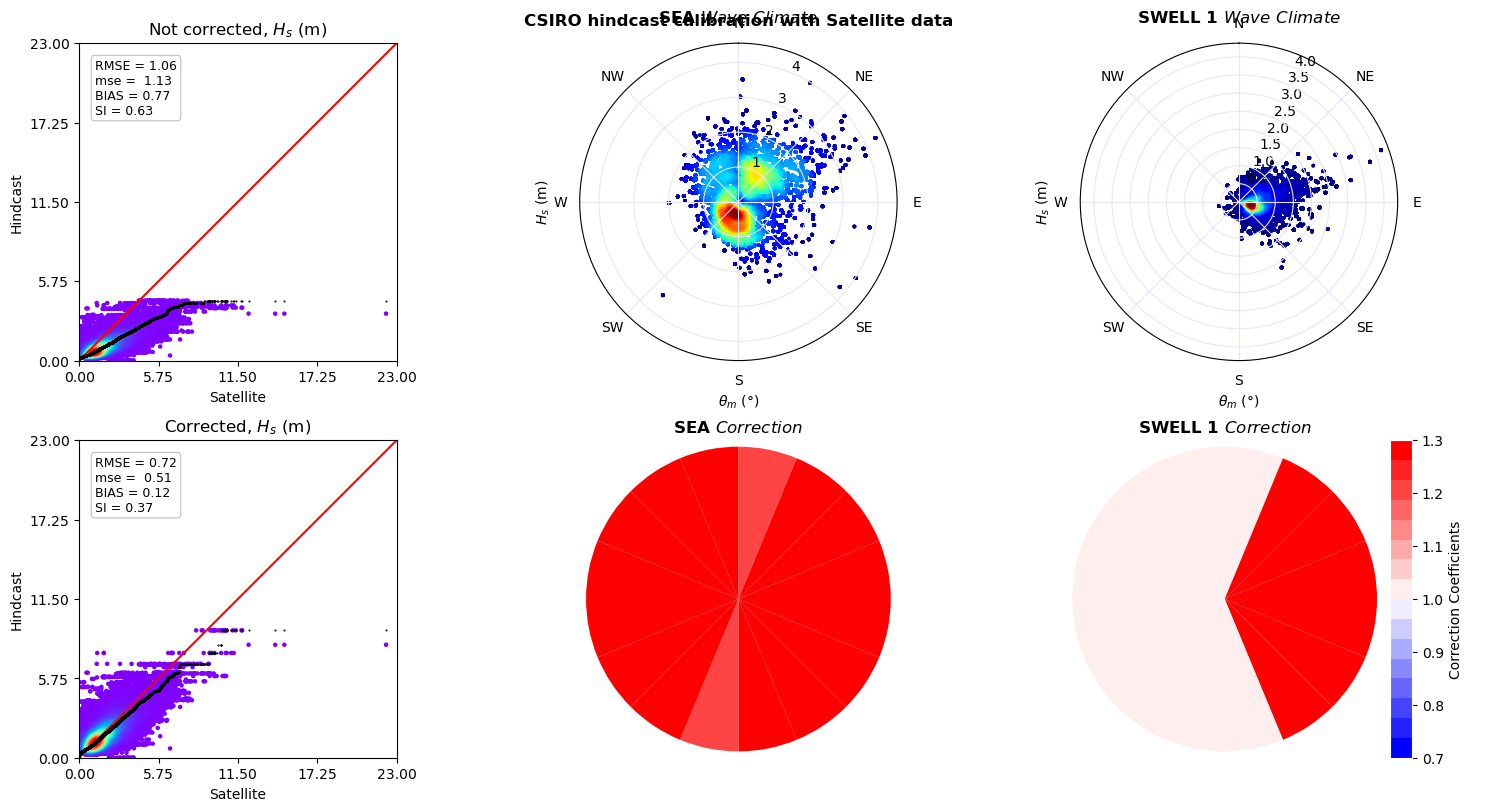

Saving corrected results... 
 
This might take more than a few minutes... 

Sea... 

0.0% completed...
25.0% completed...
50.0% completed...
75.0% completed...


Swell:1

0.0% completed...
25.0% completed...
50.0% completed...
75.0% completed...
Swell:2

0.0% completed...
25.0% completed...
50.0% completed...
75.0% completed...
 
  
 
 -------------------------------------------------------- 
BUOY CALIBRATION will be performed
 -------------------------------------------------------- 
 
 
 
Constructing matrices and calibrating... 
 
This might take a few minutes... 

Sea... 

0.0% completed...
20.0% completed...
40.0% completed...
60.0% completed...
80.0% completed...


Swells 1, 2, 3... 

0.0% completed...
20.0% completed...
40.0% completed...
60.0% completed...
80.0% completed...
0.0% completed...
20.0% completed...
40.0% completed...
60.0% completed...
80.0% completed...


Threshold of minimum Hs to calibrate
Directional families with a mean Hs under this threshold will not be cali

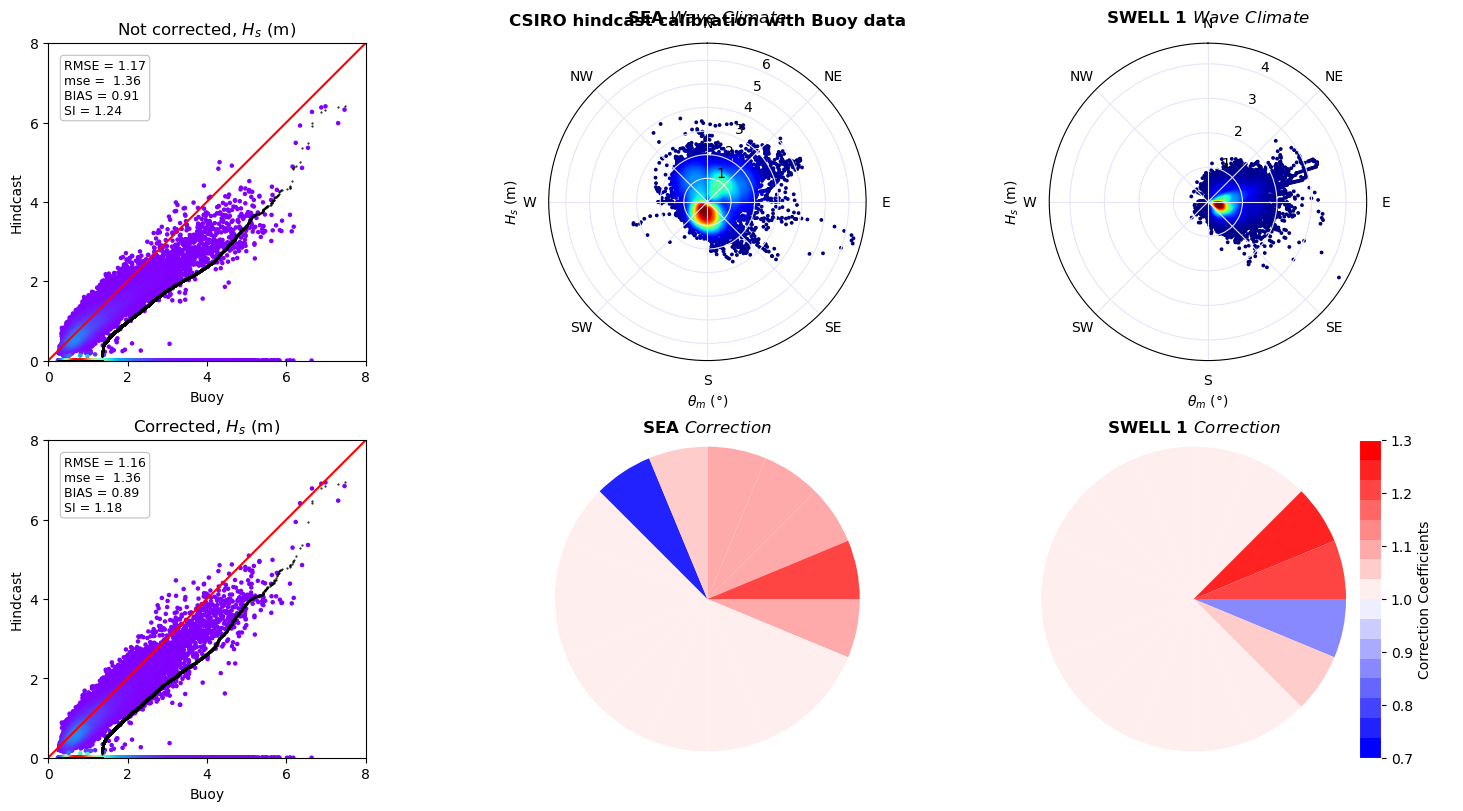

Saving corrected results... 
 
This might take more than a few minutes... 

Sea... 

0.0% completed...
25.0% completed...
50.0% completed...
75.0% completed...


Swell:1

0.0% completed...
25.0% completed...
50.0% completed...
75.0% completed...
Swell:2

0.0% completed...
25.0% completed...
50.0% completed...
75.0% completed...
 
  
 
---------------------------------------------------
Time wasted initializing the constructor: 27.17 m
---------------------------------------------------


In [6]:
## creation of the main object
# Buoy coordinates 32.5020, -79.0990

#######################################################
###   VALUES WILL HAVE TO BE INSERTED SO BE READY   ###
###   Satellite box :    South = 35.4               ###
###                      North = 33.4               ###
###                      West  = 283.4              ###
###                      East  = 285.4              ###
###   Time calibration:  False                      ###
###   Threshold :        0.01                       ###
#######################################################

# the threshold allows us to delete not relevant information

calval_case = calval.CalVal(hindcast=csiro, 
                            n_parts=3,
                            hindcast_longitude=csiro_lon,
                            hindcast_latitude=csiro_lat,
                            satellite=satellite,
                            buoy=(True,buoy.to_dataframe().rename(
                                columns={
                                    'wave_height':'Hs_Buoy',
                                    'wave_peak_period':'Tp_Buoy',
                                    'wave_mean_direction_corr':'Dir_Buoy'
                                }
                            )), buoy_longitude=buoy.longitude,
                            buoy_latitude=buoy.latitude,
                            buoy_corrections=True)

# if buoy data does not exist, just delte the buoy and buoy_correction
# attributes, and then comment the methods that use the buoy information

print('---------------------------------------------------')
print('Time wasted initializing the constructor: ' + str(round((time()-t1)/60, 2)) + ' m')
print('---------------------------------------------------')

In [12]:
t1 = time()

In [20]:
calval_case.hindcast_sat_corr.to_pickle(op.join(p_data, 'hindcast', 'csiro_dataframe_carolinas_44100_sat_corr.pkl'))
calval_case.hindcast_buoy_corr.to_pickle(op.join(p_data, 'hindcast', 'csiro_dataframe_carolinas_44100_buoy_corr.pkl'))

In [ ]:
# comparisons

#######################################################
###   VALUES WILL HAVE TO BE INSERTED SO BE READY   ###
###   Number of years :    2                        ###
###   Years :              2005 2007                ###
#######################################################

calval_case.buoy_comparison('raw',buoy_name='41108')

In [ ]:
# comparisons

#######################################################
###   VALUES WILL HAVE TO BE INSERTED SO BE READY   ###
###   Number of years :    2                        ###
###   Years :              2005 2007                ###
#######################################################

calval_case.buoy_comparison('raw',buoy_name='41108')

In [ ]:
calval_case.buoy_comparison('sat_corr',buoy_name='41108')

In [9]:
# calval_case.buoy_comparison('buoy_corr')

In [ ]:
print('---------------------------------------------------')
print('Time wasted comparing: ' + str(round((time()-t1)/60, 2)) + ' m')
print('---------------------------------------------------')

In [17]:
t1 = time()

In [ ]:
# validations

calval_case.buoy_validation('raw',buoy_name='41108')

In [ ]:
calval_case.buoy_validation('sat_corr',buoy_name='41108')

In [15]:
# calval_case.buoy_validation('buoy_corr')

In [ ]:
print('---------------------------------------------------')
print('Time wasted validating: ' + str(round((time()-t1)/60, 2)) + ' m')
print('---------------------------------------------------')

In [ ]:
print('---------------------------------------------------')
print('TOTAL time of the script: ' + str(round((time()-t0)/60, 2)) + ' m')
print('---------------------------------------------------')